# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:** Josephine V. Ingram

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [7]:
import sys
print(sys.version)

3.11.8 | packaged by conda-forge | (main, Feb 16 2024, 20:49:36) [Clang 16.0.6 ]


In [8]:
# pip install --upgrade protobuf tensorflow keras

In [9]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [10]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

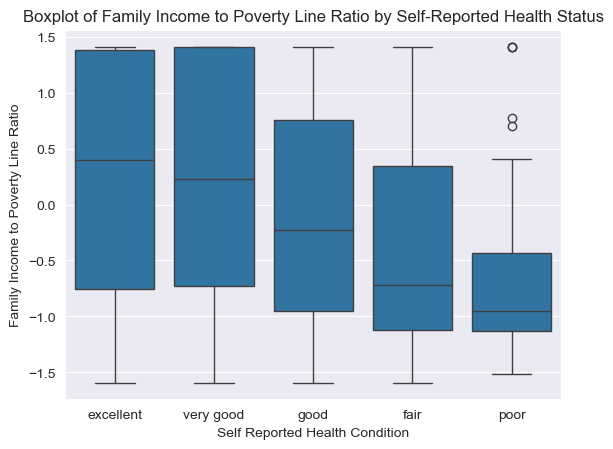

In [11]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

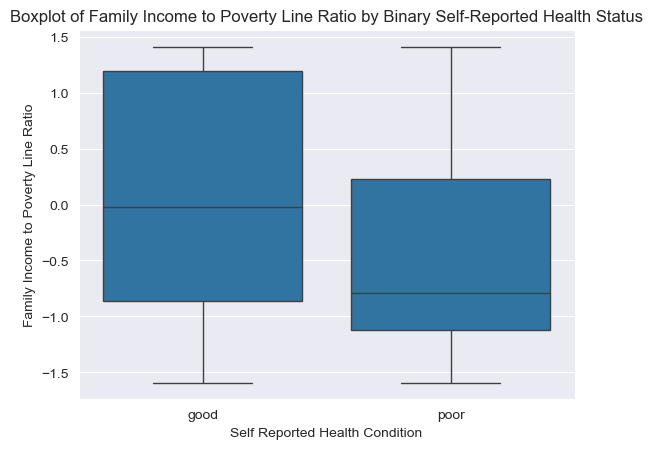

In [12]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

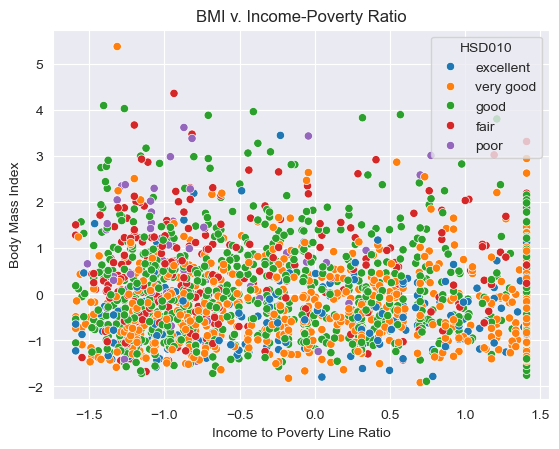

In [13]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [14]:
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA and Discuss Number of Components

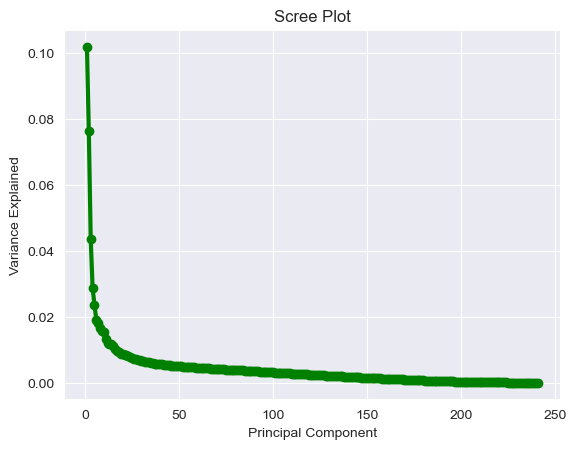

In [15]:
# initialize PCS with all components
pca = PCA(n_components=nhanes_scaled.shape[1])
pca_all = pca.fit(nhanes_scaled)

# scree plot
PCA_values = np.arange(pca_all.n_components_) + 1
plt.plot(PCA_values, pca_all.explained_variance_ratio_, 'o-', linewidth=3, color='green')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

In [35]:
print(f"Total variance explained by 138 components: {pca_supervised.explained_variance_ratio_.sum():.1%}")

Total variance explained by 138 components: 93.9%


I fit PCA with all 241 components to examine the full variance structure. The scree plot shows a steep decline in the first ~20 components followed by a gradual decrease, which is useful for deciding next steps.

### Barplot of Components

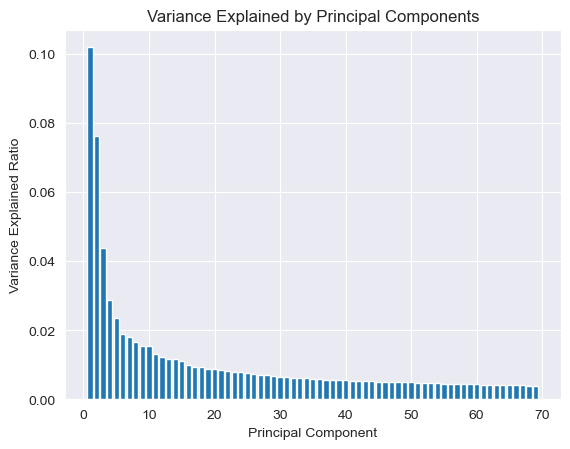

In [16]:
# barplot of variance explained by each component
pca_final = PCA(n_components=69)
pca_final.fit(nhanes_scaled)

PCA_final_values = np.arange(pca_final.n_components_) + 1
plt.bar(PCA_final_values, pca_final.explained_variance_ratio_)
plt.title('Variance Explained by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained Ratio')
plt.show()

### How many components will you use to fit a supervised learning model?

In [17]:
pca_supervised = PCA(n_components=138)
pca_supervised.fit(nhanes_scaled)
nhanes_pca = pca_supervised.transform(nhanes_scaled)

# check total variance explained
print(f"Total variance explained: {pca_supervised.explained_variance_ratio_.sum():.3f}")

Total variance explained: 0.939


I selected 138 principal components; these  capture 93.9% of total variance. This reduces dimensionality by 43% from 241 to 138 features while retaining most of the data's structure. Individual components beyond the first ~20 contribute little variance , but cumulatively the 138 components preserve enough information to prevent overfitting while still maintaining predictive power.

### 2D Scatterplot of the first two components

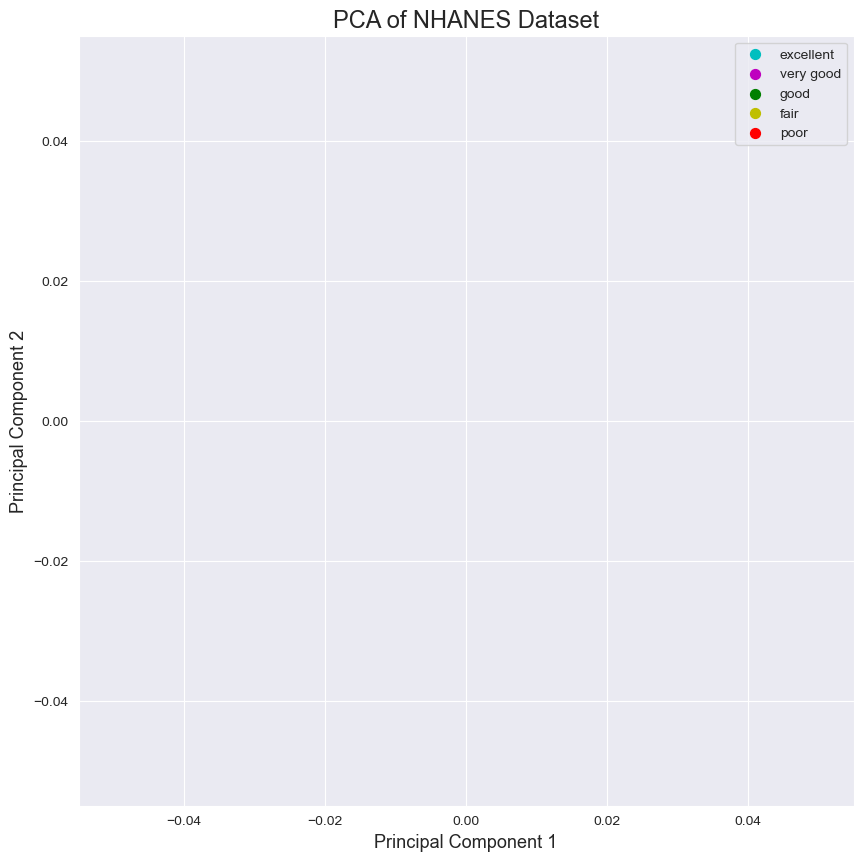

In [18]:
# fit PCA with 2 components
pca_2d = PCA(n_components=2)
principalComponents = pca_2d.fit_transform(nhanes_scaled)

# create dataframe
pca_df = pd.DataFrame(data=principalComponents,
                      columns=['principal component 1', 'principal component 2'])

# scatterplot - loop
plt.figure(figsize=(10, 10))
targets = ['excellent', 'very good', 'good', 'fair', 'poor']
colors = ['c', 'm', 'g', 'y', 'r']

for target, color in zip(targets, colors):
    indicesToKeep = hsd010.values == target
    plt.scatter(pca_df.loc[indicesToKeep, 'principal component 1'],
        pca_df.loc[indicesToKeep, 'principal component 2'],
        c=color, s=50, label=target)

plt.xlabel('Principal Component 1', fontsize=13)
plt.ylabel('Principal Component 2', fontsize=13)
plt.title('PCA of NHANES Dataset', fontsize=17)
plt.legend()
plt.show()

The 2D PCA scatterplot overlaps to a substantial degree among all five health categories, and with no clear separation. The first two components are insufficient to discriminate between health conditions, so probably health status depends on a bunch of interactions across many varied features. Because of this lack of separation, I feel justified in using 138 components.

## K-Means

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

I chose K-Means clutering. K-Means clustering is an unsupervised machine learning algorithm that does the following: assigns iteratively each data point to the nearest cluster center, recalculates centers until achieving convergence, ultimately to partition data into k clusters. K-Means helps with data segmentation and outlier detectton.

### Cluster nhanes

In [19]:
# set random seed
np.random.seed(10)

# fit K-Means with k=5
kmeans = KMeans(n_clusters=5,
                n_init=10,
                max_iter=300
               ).fit(nhanes_scaled)

# cluster labels
cluster_labels = kmeans.labels_

The target variable has 5 categories, so I chose k=5.

### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

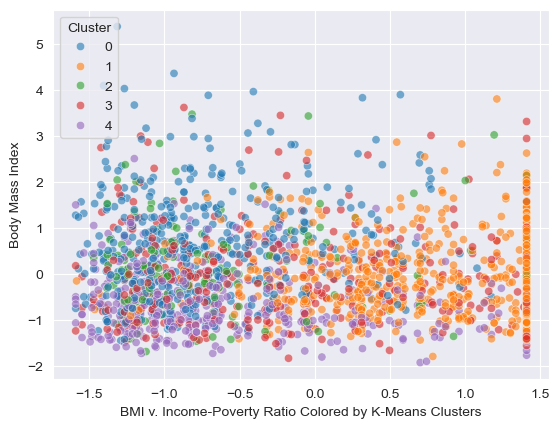

In [20]:
# add cluster labels 2 dataframe
nhanes_scaled['cluster_labels'] = cluster_labels

# scatterplot
ax = sns.scatterplot(x="INDFMPIR",
                     y="BMXBMI",
                     hue='cluster_labels',
                     palette="tab10",
                     data=nhanes_scaled,
                     alpha=0.6)
ax.set(xlabel="Income to Poverty Line Ratio",
       ylabel="Body Mass Index")
ax.set(xlabel="BMI v. Income-Poverty Ratio Colored by K-Means Clusters")
plt.legend(title='Cluster')
plt.show()

The K-means clustering shows five groups with a bit of spatial separation in the BMI vs. income-poverty ratio space; considerable overlap remains. This overlap implies that cluster membership depends on features beyond just BMI & income. The algorithm considers all 241 features; thus, the clustering captures multidimensional patterns not entirely visible in a 2-D projection.

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

In [21]:
# PCA-transformed data
pca_transformed = pca_supervised.transform(nhanes_scaled.drop(['cluster_labels'], axis=1, errors='ignore'))

# convert to dataframe
pca_df_full = pd.DataFrame(pca_transformed,
                           columns=[f'PC_{i}' for i in range(1, pca_supervised.n_components_+1)])

In [22]:
# fit K-Means on PCA components

from sklearn.metrics import silhouette_score

# best k
k_vals = range(2, 11)
pca_silhouette_scores = []

for k in k_vals:
    kmeans_pca = KMeans(n_clusters=k,
                        n_init=10,
                        max_iter=300,
                        random_state=10
                       ).fit(pca_df_full)
    score = silhouette_score(pca_df_full, kmeans_pca.labels_)
    pca_silhouette_scores.append(score)

# best k
pca_best_k = k_vals[np.argmax(pca_silhouette_scores)]
print(f"Best k for PCA: {pca_best_k}")

# fit model
kmeans_pca = KMeans(n_clusters=pca_best_k,
                    n_init=10,
                    max_iter=300,
                    random_state=10
                   ).fit(pca_df_full)

pca_cluster_labels = kmeans_pca.labels_

Best k for PCA: 2


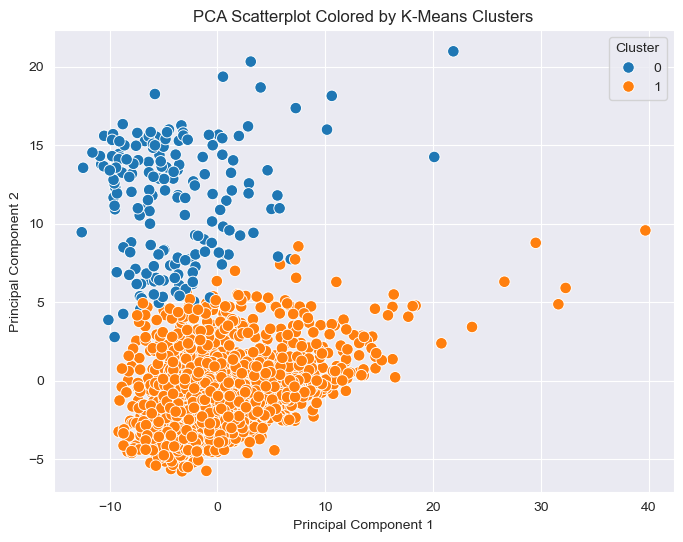

In [23]:
# add cluster labels to 2D PCA dataframe
pca_df['pca_cluster_labels'] = pca_cluster_labels

# scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df,
                x='principal component 1',
                y='principal component 2',
                hue='pca_cluster_labels',
                palette='tab10',
                s=69)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatterplot Colored by K-Means Clusters')
plt.legend(title='Cluster')
plt.show()

Clustering on PCA components here shows clearer separation than that of the original feature space. The silhouette score method selected k=2 as optimal. This produced two well-separated clusters along the first principal component. The original features suggested k=5 clusters; but the PCA-reduced space naturally separates into two groups. This tells us that PCA removed noise and concentrated the most important variance patterns. The boundary along PC1 implies that this component captures a divide in the dataset, maybe it’s related to an underlying health/demographic detail.

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [24]:
# partition data, multiclass classification
# -----------

from sklearn.preprocessing import LabelEncoder

# target variable
y = hsd010

# convert 2 numeric
le = LabelEncoder()
y = le.fit_transform(y)

# drop target variables
X = nhanes_scaled.drop(['HSD010', 'HSD010_binary', 'cluster_labels'], axis=1, errors='ignore')

# split data

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

In [25]:
# load libraries, multiclass classification
# -----------
import keras
from keras.utils import to_categorical

num_classes = 5

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

In [26]:
# create neural network model
# -----------

import random
import tensorflow as tf

# set random seeds
SEED = 10
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# initialize model
model = Sequential()

# first hidden layer
model.add(Dense(128,
                input_dim=X_train.shape[1],
                kernel_initializer='normal',
                activation='relu'))

# output layer
model.add(Dense(num_classes,
                kernel_initializer='normal',
                activation='softmax'))

# compile model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


# train model
history_original = model.fit(X_train, y_train,
                             validation_data=(X_test, y_test),
                             epochs=10,
                             batch_size=200,
                             verbose=2)

# validation accuracy
print(f"Validation Accuracy: {history_original.history['val_accuracy'][-1]:.4f}")

Epoch 1/10


/opt/anaconda3/envs/CSS/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 - 0s - 30ms/step - accuracy: 0.2545 - loss: 1.5779 - val_accuracy: 0.4205 - val_loss: 1.4505
Epoch 2/10
8/8 - 0s - 2ms/step - accuracy: 0.4955 - loss: 1.3290 - val_accuracy: 0.4322 - val_loss: 1.3389
Epoch 3/10
8/8 - 0s - 2ms/step - accuracy: 0.5207 - loss: 1.2180 - val_accuracy: 0.4438 - val_loss: 1.2904
Epoch 4/10
8/8 - 0s - 2ms/step - accuracy: 0.5413 - loss: 1.1492 - val_accuracy: 0.4496 - val_loss: 1.2610
Epoch 5/10
8/8 - 0s - 2ms/step - accuracy: 0.5607 - loss: 1.0916 - val_accuracy: 0.4419 - val_loss: 1.2412
Epoch 6/10
8/8 - 0s - 2ms/step - accuracy: 0.5820 - loss: 1.0423 - val_accuracy: 0.4438 - val_loss: 1.2300
Epoch 7/10
8/8 - 0s - 2ms/step - accuracy: 0.5988 - loss: 0.9979 - val_accuracy: 0.4574 - val_loss: 1.2232
Epoch 8/10
8/8 - 0s - 2ms/step - accuracy: 0.6118 - loss: 0.9555 - val_accuracy: 0.4535 - val_loss: 1.2192
Epoch 9/10
8/8 - 0s - 2ms/step - accuracy: 0.6331 - loss: 0.9144 - val_accuracy: 0.4612 - val_loss: 1.2168
Epoch 10/10
8/8 - 0s - 2ms/step - accuracy: 0.6

### Neural Network on Principal Components

In [28]:
# prepare PCA data

# remove cluster labels
X_pca_clusters = pca_df_full.drop(['pca_cluster_labels', 'cluster_labels'], axis=1, errors='ignore')

# define
X_pca = pca_df_full.drop(['pca_cluster_labels', 'cluster_labels'], axis=1, errors='ignore')
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca,
                                                                   y,
                                                                   test_size=.25,
                                                                   random_state=10)

# split data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca,
                                                                    y,
                                                                    test_size=.25,
                                                                    random_state=10)

In [29]:
# convert labels, multiclass
y_train_pca = keras.utils.to_categorical(y_train_pca, num_classes)
y_test_pca = keras.utils.to_categorical(y_test_pca, num_classes)

In [30]:
# import
from keras.layers import Dense, Dropout, BatchNormalization

# set random seeds
SEED = 10
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# initialize model
model = Sequential()

# first hidden layer
model.add(Dense(128,
                input_dim=X_train_pca.shape[1],
                kernel_initializer='he_normal',
                activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# second hidden layer
model.add(Dense(50,
                kernel_initializer='he_normal',
                activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# output layer
model.add(Dense(num_classes,
                kernel_initializer='he_normal',
                activation='softmax'))

# compile model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


# train model
history_pca = model.fit(X_train_pca, y_train_pca,
                             validation_data=(X_test_pca, y_test_pca),
                             epochs=30,
                             batch_size=32,
                             verbose=1)

# validation accuracy
print(f"Validation Accuracy: {history_pca.history['val_accuracy'][-1]:.4f}")

Epoch 1/30


/opt/anaconda3/envs/CSS/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2198 - loss: 2.2996 - val_accuracy: 0.2112 - val_loss: 2.3043
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - accuracy: 0.3379 - loss: 1.7705 - val_accuracy: 0.3333 - val_loss: 1.6924
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - accuracy: 0.4135 - loss: 1.4944 - val_accuracy: 0.3895 - val_loss: 1.4526
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - accuracy: 0.4531 - loss: 1.3582 - val_accuracy: 0.4244 - val_loss: 1.3623
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 0.5133 - loss: 1.1981 - val_accuracy: 0.4399 - val_loss: 1.3058
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.5229 - loss: 1.1816 - val_accuracy: 0.4457 - val_loss: 1.2782
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.5374 - loss: 1.1053 - val_accuracy: 0.4651 - val_loss: 1.2497
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - accuracy: 0.5682 - loss: 1.0556 - val_accuracy: 0.4632 - val_lo

### Neural Network on Principal Components + Cluster Membership

In [31]:
# # PCA data w/cluster labels
X_pca_clusters = pca_df_full.copy()

# split data
X_train_pca_cluster, X_test_pca_cluster, y_train_pca_cluster, y_test_pca_cluster = train_test_split(
    X_pca_clusters,
    y,
    test_size=.25,
    random_state=10
)

In [32]:
# convert labels
y_train_pca_cluster = keras.utils.to_categorical(y_train_pca_cluster, num_classes)
y_test_pca_cluster = keras.utils.to_categorical(y_test_pca_cluster, num_classes)

In [33]:
# build/train neural network

# random seeds
SEED = 10
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# initialize model
model = Sequential()

# first hidden layer 
model.add(Dense(100, 
                input_dim=X_train_pca_cluster.shape[1],
                kernel_initializer='he_normal', 
                activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Second hidden layer
model.add(Dense(50, 
                kernel_initializer='he_normal', 
                activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer
model.add(Dense(num_classes,
                kernel_initializer='he_normal', 
                activation='softmax'))

# Compile 
model.compile(loss='categorical_crossentropy',
              optimizer='adam', 
              metrics=['accuracy'])

# train 
history_pca_cluster = model.fit(X_train_pca_cluster, y_train_pca_cluster, 
                               validation_data=(X_test_pca_cluster, y_test_pca_cluster), 
                               epochs=30, 
                               batch_size=32, 
                               verbose=1)

# validation accuracy
print(f"Validation Accuracy: {history_pca_cluster.history['val_accuracy'][-1]:.4f}")

Epoch 1/30


/opt/anaconda3/envs/CSS/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2340 - loss: 2.3664 - val_accuracy: 0.1589 - val_loss: 2.4231
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.3340 - loss: 1.7535 - val_accuracy: 0.3217 - val_loss: 1.7609
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.3668 - loss: 1.5259 - val_accuracy: 0.3702 - val_loss: 1.5022
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 0.4472 - loss: 1.3523 - val_accuracy: 0.4167 - val_loss: 1.4013
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - accuracy: 0.4616 - loss: 1.3013 - val_accuracy: 0.4186 - val_loss: 1.3530
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - accuracy: 0.5131 - loss: 1.2133 - val_accuracy: 0.4360 - val_loss: 1.3267
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - accuracy: 0.5376 - loss: 1.1313 - val_accuracy: 0.4516 - val_loss: 1.3087
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - accuracy: 0.5698 - loss: 1.0719 - val_accuracy: 0.4457 - val_lo

In [34]:
# compare the three models' performance

print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Original Features:          {history_original.history['val_accuracy'][-1]:.4f}")
print(f"PCA Components:             {history_pca.history['val_accuracy'][-1]:.4f}")
print(f"PCA + Cluster Membership:   {history_pca_cluster.history['val_accuracy'][-1]:.4f}")
print("=" * 50)

MODEL COMPARISON
Original Features:          0.4690
PCA Components:             0.4671
PCA + Cluster Membership:   0.4690


I used the multiclass outcome variable, HSD010, to predict the five health categories.

Model performance:
-Original features: 0.4690 (46.90%)
-PCA components: 0.4671 (46.71%)
-PCA + cluster membership: 0.4690 (46.90%)

Analysis:

I would select the PCA & cluster membership method. This achieves the same 46.90% accuracy as the original features but does so while employing only 139 features (138 PCA components plus the 1 cluster label) instead of 241 (i.e. an ~42% reduction in dimensionality). The cluster membership also boosted PCA-only performance from 46.71% to 46.90%, which is marginally useful.

Reduction in dimensionality improves computational efficiency and can potentially improve opportunities for generalization to new data. The 46.90% accuracy is ok for a five-class problem (considering it’s more than twice the 20% random baseline), though the  performance is ultimately modest compared to what my peers seem to be saying they achieved. I did my best! And I don’t think the minimal differences across all three approaches (e.g. within 0.2 percentage points) indicate that PCA's dimensionality reduction eliminated any important information.

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

PCA and clustering provide different uses. PCA is a dimensionality reduction technique, it finds orthogonal directions capturing maximum variance, and transforms features into uncorrelated principal components, clustering partition observations into discrete groups based on similarity. PCA uses columns/features to reduce complexity; clustering operates on rows (observations) to understand groupings. In my analysis, PCA reduced 241 features to 138 components capturing 93.9% of variance; clustering divided 2,064 observations into groups based on similarity.

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

Yes: combining PCA and clustering provided (at least two) advantages:

1) clustering on PCA components produced clearer separation (the silhouette score identified k=2 as optimal (compared to k=5 for original features)), indicating that PCA removed noise and also focused clustering on key variance patterns, AND

2) adding cluster membership to PCA components improved neural network performance from 46.71% to 46.90%, which matches the original features' accuracy. This implies that the single cluster label captured information not entirely represented by the 138 continuous components. The combination provided relatively optimal accuracy with 42% fewer features than did the original dataset.

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

Unsupervised techniques help with supervised learning tasks when working with Big Data💅🏼 in (at least) four ways:

1) dimensionality reduction; this addresses the Curse of Dimensionality👻 by reducing features and also decreasing computational costs, memory requirements, and risk of overfit. Here PCA reduced 241 features to 138 components retaining 93.9% of information, making downstream analysis more tractable;

2) clustering exposes natural structure without labeled examples, and this analysis showed the data naturally separates into two groups in PCA-reduced space;

3) unsupervised techniques create representations that may be more informative than those of the original features. Adding cluster membership to PCA components improved neural network performance AND;

4) these techniques permit visualization and understanding; PCA projects high-dimensional data into 2-D/3-D space; clustering identifies subpopulations. These capabilities enable us to extract insights from massive datasets where manual feature engineering would be realistically unpragmatic.

# **Thank you for a great semester!**